# Developer Clustering

Segments all developers into 4 tiers: **beginner**, **experienced**, **advanced**, **enterprise**.

**Run order:** `Cleaning_Final.ipynb` first, then this notebook.
**If re-running:** Kernel → Restart & Clear Output → Run All

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

con = duckdb.connect("developer_project.duckdb")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

SEED = 42
N_CLUSTERS = 4
TIER_ORDER  = ["beginner", "experienced", "advanced", "enterprise"]
TIER_COLORS = {"beginner": "#90CAF9", "experienced": "#66BB6A",
               "advanced": "#FFA726",  "enterprise":  "#EF5350"}

FEATURE_COLS = [
    "total_activities", "total_score", "avg_score", "max_score",
    "distinct_activity_types", "high_value_activities", "presenter_activities",
    "dli_count", "dli_instructor_led", "dli_self_paced",
    "api_count", "container_count", "model_count", "helm_count", "ngc_downloads",
    "conference_count", "forum_count", "bug_count", "hackathon_count",
    "webinar_count", "presenter_role_count",
    "activity_span_days", "days_since_last_activity",
    "is_enterprise", "is_university", "is_startup",
    "has_account", "is_wwfo_targeted",
    "tenure_days", "development_areas_count", "fields_of_interest_count",
]

LOG_COLS = [
    "total_activities", "total_score", "dli_count", "dli_instructor_led",
    "dli_self_paced", "api_count", "container_count", "model_count",
    "helm_count", "ngc_downloads", "conference_count", "forum_count",
    "bug_count", "hackathon_count", "webinar_count", "presenter_role_count",
    "high_value_activities", "presenter_activities", "activity_span_days", "tenure_days",
]

print("Setup complete")

c:\Users\ldcal\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Setup complete


## Section 1 — Feature Engineering

In [2]:
con.execute("""
CREATE OR REPLACE TABLE dev_activity_features AS
SELECT
    dev_contact AS developer_id,
    COUNT(*)                                                                           AS total_activities,
    SUM(activity_score)                                                                AS total_score,
    AVG(activity_score)                                                                AS avg_score,
    MAX(activity_score)                                                                AS max_score,
    COUNT(DISTINCT activity)                                                           AS distinct_activity_types,
    SUM(CASE WHEN activity_score >= 20   THEN 1 ELSE 0 END)                           AS high_value_activities,
    SUM(CASE WHEN activity_score = 100   THEN 1 ELSE 0 END)                           AS presenter_activities,
    SUM(CASE WHEN activity = 'dli training'            THEN 1 ELSE 0 END)             AS dli_count,
    SUM(CASE WHEN activity_type = 'instructor-led'     THEN 1 ELSE 0 END)             AS dli_instructor_led,
    SUM(CASE WHEN activity_type = 'self-paced online'  THEN 1 ELSE 0 END)             AS dli_self_paced,
    SUM(CASE WHEN activity = 'model api'               THEN 1 ELSE 0 END)             AS api_count,
    SUM(CASE WHEN activity_type = 'container'          THEN 1 ELSE 0 END)             AS container_count,
    SUM(CASE WHEN activity_type = 'model'              THEN 1 ELSE 0 END)             AS model_count,
    SUM(CASE WHEN activity_type = 'helm chart'         THEN 1 ELSE 0 END)             AS helm_count,
    SUM(CASE WHEN activity = 'ngc downloads'           THEN 1 ELSE 0 END)             AS ngc_downloads,
    SUM(CASE WHEN activity IN ('conf. sessions live','conference') THEN 1 ELSE 0 END) AS conference_count,
    SUM(CASE WHEN activity = 'forum contributions'     THEN 1 ELSE 0 END)             AS forum_count,
    SUM(CASE WHEN activity = 'bugs filed'              THEN 1 ELSE 0 END)             AS bug_count,
    SUM(CASE WHEN activity = 'hackathons'              THEN 1 ELSE 0 END)             AS hackathon_count,
    SUM(CASE WHEN activity = 'webinars'                THEN 1 ELSE 0 END)             AS webinar_count,
    SUM(CASE WHEN activity_role = 'presenter/speaker'  THEN 1 ELSE 0 END)             AS presenter_role_count,
    DATEDIFF('day', MIN(activity_date), MAX(activity_date))                           AS activity_span_days,
    DATEDIFF('day', MAX(activity_date), CURRENT_DATE)                                 AS days_since_last_activity
FROM activity_final
GROUP BY dev_contact
""")
print(f"dev_activity_features: {con.execute('SELECT COUNT(*) FROM dev_activity_features').fetchone()[0]:,} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

dev_activity_features: 7,654,427 rows


In [3]:
con.execute("""
CREATE OR REPLACE TABLE dev_contact_features AS
SELECT
    developer_id,
    CASE WHEN LOWER(account_type) LIKE '%enterprise%' THEN 1 ELSE 0 END           AS is_enterprise,
    CASE WHEN LOWER(account_type) LIKE '%university%' THEN 1 ELSE 0 END           AS is_university,
    CASE WHEN LOWER(account_type) LIKE '%startup%'    THEN 1 ELSE 0 END           AS is_startup,
    CASE WHEN account_id IS NOT NULL AND account_id != '' THEN 1 ELSE 0 END       AS has_account,
    CASE WHEN wwfo_target_list IS NOT NULL
          AND wwfo_target_list NOT IN ('unknown','null','') THEN 1 ELSE 0 END      AS is_wwfo_targeted,
    COALESCE(DATEDIFF('day', first_program_application_date, CURRENT_DATE), 0)    AS tenure_days,
    CASE WHEN development_areas IS NULL OR development_areas = 'unknown' THEN 0
         ELSE LENGTH(development_areas) - LENGTH(REPLACE(development_areas,';','')) + 1
    END                                                                            AS development_areas_count,
    CASE WHEN fields_of_interest IS NULL OR fields_of_interest = 'unknown' THEN 0
         ELSE LENGTH(fields_of_interest) - LENGTH(REPLACE(fields_of_interest,';','')) + 1
    END                                                                            AS fields_of_interest_count
FROM contact_final
""")
print(f"dev_contact_features: {con.execute('SELECT COUNT(*) FROM dev_contact_features').fetchone()[0]:,} rows")

dev_contact_features: 9,381,490 rows


In [4]:
con.execute("""
CREATE OR REPLACE TABLE developer_features AS
SELECT
    c.developer_id,
    COALESCE(a.total_activities,         0)    AS total_activities,
    COALESCE(a.total_score,              0)    AS total_score,
    COALESCE(a.avg_score,                0)    AS avg_score,
    COALESCE(a.max_score,                0)    AS max_score,
    COALESCE(a.distinct_activity_types,  0)    AS distinct_activity_types,
    COALESCE(a.high_value_activities,    0)    AS high_value_activities,
    COALESCE(a.presenter_activities,     0)    AS presenter_activities,
    COALESCE(a.dli_count,                0)    AS dli_count,
    COALESCE(a.dli_instructor_led,       0)    AS dli_instructor_led,
    COALESCE(a.dli_self_paced,           0)    AS dli_self_paced,
    COALESCE(a.api_count,                0)    AS api_count,
    COALESCE(a.container_count,          0)    AS container_count,
    COALESCE(a.model_count,              0)    AS model_count,
    COALESCE(a.helm_count,               0)    AS helm_count,
    COALESCE(a.ngc_downloads,            0)    AS ngc_downloads,
    COALESCE(a.conference_count,         0)    AS conference_count,
    COALESCE(a.forum_count,              0)    AS forum_count,
    COALESCE(a.bug_count,                0)    AS bug_count,
    COALESCE(a.hackathon_count,          0)    AS hackathon_count,
    COALESCE(a.webinar_count,            0)    AS webinar_count,
    COALESCE(a.presenter_role_count,     0)    AS presenter_role_count,
    COALESCE(a.activity_span_days,       0)    AS activity_span_days,
    COALESCE(a.days_since_last_activity, 1825) AS days_since_last_activity,
    c.is_enterprise,
    c.is_university,
    c.is_startup,
    c.has_account,
    c.is_wwfo_targeted,
    c.tenure_days,
    c.development_areas_count,
    c.fields_of_interest_count
FROM dev_contact_features c
LEFT JOIN dev_activity_features a ON c.developer_id = a.developer_id
""")
n = con.execute("SELECT COUNT(*) FROM developer_features").fetchone()[0]
print(f"developer_features: {n:,} developers")
display(con.execute("SELECT * FROM developer_features LIMIT 3").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

developer_features: 9,381,490 developers


,developer_id,total_activities,total_score,avg_score,max_score,distinct_activity_types,high_value_activities,presenter_activities,dli_count,dli_instructor_led,dli_self_paced,api_count,container_count,model_count,helm_count,ngc_downloads,conference_count,forum_count,bug_count,hackathon_count,webinar_count,presenter_role_count,activity_span_days,days_since_last_activity,is_enterprise,is_university,is_startup,has_account,is_wwfo_targeted,tenure_days,development_areas_count,fields_of_interest_count
0,8834557,2,21.00,10.50,20.00,2,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,358,0,1,0,1,0,358,7,1
1,8834778,2,4.00,2.00,3.00,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,358,0,0,0,1,0,358,1,1
2,8834704,2,21.00,10.50,20.00,2,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,358,0,1,0,1,0,358,4,1


## Section 2 — Preprocessing

In [5]:
df = con.execute("SELECT * FROM developer_features").df()
developer_ids = df["developer_id"].values

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

X_raw = df[FEATURE_COLS].copy()
print(f"Feature matrix: {X_raw.shape}")
display(X_raw.describe())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature matrix: (9381490, 31)


,total_activities,total_score,avg_score,max_score,distinct_activity_types,high_value_activities,presenter_activities,dli_count,dli_instructor_led,dli_self_paced,api_count,container_count,model_count,helm_count,ngc_downloads,conference_count,forum_count,bug_count,hackathon_count,webinar_count,presenter_role_count,activity_span_days,days_since_last_activity,is_enterprise,is_university,is_startup,has_account,is_wwfo_targeted,tenure_days,development_areas_count,fields_of_interest_count
count,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00,9381490.00
mean,7.28,24.28,3.14,4.93,1.58,0.18,0.00,0.18,0.04,0.15,0.69,0.57,0.07,0.05,0.82,0.18,0.01,0.01,0.00,0.03,0.00,102.98,1040.36,0.08,0.21,0.03,1.00,0.19,788.05,2.48,0.95
std,722.62,3552.71,4.37,8.03,1.09,0.95,0.38,0.85,0.30,0.74,23.10,683.16,15.43,40.51,719.45,2.80,2.22,2.45,0.01,0.34,0.38,309.79,678.58,0.27,0.41,0.16,0.00,0.39,856.42,2.23,0.22
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,47.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,411.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00
50%,2.00,4.00,2.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,954.00,0.00,0.00,0.00,1.00,0.00,495.00,2.00,1.00
75%,3.00,13.00,2.99,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1825.00,0.00,0.00,0.00,1.00,0.00,1330.00,3.00,1.00
max,2027375.00,10015777.00,100.00,100.00,15.00,970.00,970.00,194.00,102.00,157.00,36771.00,1918736.00,16014.00,104258.00,2027374.00,6266.00,3582.00,5893.00,4.00,125.00,970.00,2261.00,2309.00,1.00,1.00,1.00,1.00,1.00,7787.00,17.00,1.00


In [6]:
X = X_raw.copy()
for col in LOG_COLS:
    X[col] = np.log1p(X[col])
X["days_since_last_activity"] = np.log1p(X["days_since_last_activity"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled: {X_scaled.shape}  |  NaN present: {np.isnan(X_scaled).any()}")

Scaled: (9381490, 31)  |  NaN present: False


## Section 3 — Clustering

  k=2: inertia=1287191
  k=3: inertia=1192221
  k=4: inertia=1108044
  k=5: inertia=1042249
  k=6: inertia=1004535
  k=7: inertia=983282
  k=8: inertia=927634


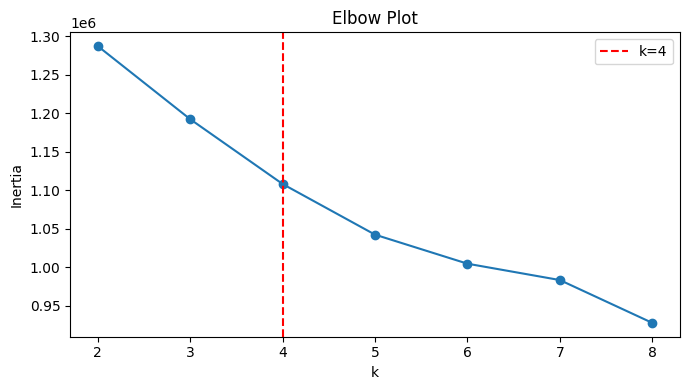

In [7]:
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_scaled), size=min(50_000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

ks, inertias = range(2, 9), []
for k in ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=3, batch_size=10_000)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"  k={k}: inertia={km.inertia_:.0f}")

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, marker="o")
plt.axvline(x=4, color="red", linestyle="--", label="k=4")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.title("Elbow Plot"); plt.legend(); plt.tight_layout(); plt.show()

In [8]:
print(f"Fitting MiniBatchKMeans (k={N_CLUSTERS}) on {len(X_scaled):,} developers...")
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED,
                         n_init=10, batch_size=50_000, max_iter=300)
cluster_ids = kmeans.fit_predict(X_scaled)

unique, counts = np.unique(cluster_ids, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n:,} ({n/len(cluster_ids)*100:.1f}%)")

Fitting MiniBatchKMeans (k=4) on 9,381,490 developers...
  Cluster 0: 2,307,163 (24.6%)
  Cluster 1: 1,079,591 (11.5%)
  Cluster 2: 3,672,016 (39.1%)
  Cluster 3: 2,322,720 (24.8%)


In [9]:
sil_idx = np.random.choice(len(X_scaled), size=10_000, replace=False)
sil = silhouette_score(X_scaled[sil_idx], cluster_ids[sil_idx])
print(f"Silhouette score (10k sample): {sil:.4f}  (>0.3 reasonable, >0.5 strong)")

Silhouette score (10k sample): 0.1789  (>0.3 reasonable, >0.5 strong)


## Section 4 — Cluster Labeling

In [10]:
# All variables used here are defined in this cell — no dependency on prior cell state
LABEL_FEATURES = [
    "total_activities", "total_score", "avg_score", "max_score",
    "distinct_activity_types",
    "dli_count", "dli_instructor_led", "dli_self_paced",
    "api_count", "container_count",
    "hackathon_count", "forum_count", "bug_count", "presenter_role_count",
    "is_enterprise", "has_account", "is_wwfo_targeted",
    "tenure_days", "days_since_last_activity",
]

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURE_COLS
)
centroids_df.index.name = "cluster_id"

# Verify all LABEL_FEATURES are present before ranking
missing_lf = [f for f in LABEL_FEATURES if f not in centroids_df.columns]
if missing_lf:
    raise ValueError(f"Label features missing from centroids: {missing_lf}")

print("Centroid values (original scale):")
display(centroids_df[LABEL_FEATURES].round(2))

rank = centroids_df[LABEL_FEATURES].rank(ascending=True)

tier_scores = pd.DataFrame({
    "enterprise":  rank[["is_enterprise", "has_account", "is_wwfo_targeted"]].mean(axis=1),
    "advanced":    rank[["max_score", "dli_instructor_led", "hackathon_count",
                          "forum_count", "bug_count", "presenter_role_count"]].mean(axis=1),
    "experienced": rank[["total_score", "api_count", "dli_self_paced",
                          "container_count", "distinct_activity_types"]].mean(axis=1),
    "beginner":    rank[["days_since_last_activity"]].mean(axis=1),
})

print("\nTier scores per cluster:")
display(tier_scores)

cluster_label_map = {}
used = set()
for tier in ["enterprise", "advanced", "experienced", "beginner"]:
    best = tier_scores[tier].drop(index=list(used)).idxmax()
    cluster_label_map[best] = tier
    used.add(best)

print("\nAssigned labels:")
for cid, lbl in sorted(cluster_label_map.items()):
    print(f"  Cluster {cid} -> {lbl}")

labels = np.array([cluster_label_map[c] for c in cluster_ids])

Centroid values (original scale):


,total_activities,total_score,avg_score,max_score,distinct_activity_types,dli_count,dli_instructor_led,dli_self_paced,api_count,container_count,hackathon_count,forum_count,bug_count,presenter_role_count,is_enterprise,has_account,is_wwfo_targeted,tenure_days,days_since_last_activity
cluster_id,,,,,,,,,,,,,,,,,,,
0,0.17,0.36,0.99,0.99,0.24,-0.00,0.00,-0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.08,1.00,0.07,0.03,7.27
1,1.45,3.60,12.75,24.57,2.38,0.86,0.18,0.70,0.03,0.04,0.00,0.00,0.00,0.00,0.12,1.00,0.24,6.14,6.08
2,1.05,1.26,1.64,2.12,1.59,0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,0.07,1.00,0.11,6.01,6.22
3,1.96,2.84,3.03,3.92,2.42,0.00,0.00,0.00,0.02,0.04,0.00,0.01,0.00,0.00,0.09,1.00,0.38,6.74,6.74



Tier scores per cluster:


,enterprise,advanced,experienced,beginner
cluster_id,,,,
0,1.83,1.67,1.20,4.00
1,3.17,3.33,3.60,1.00
2,1.83,1.83,2.20,2.00
3,3.17,3.17,3.00,3.00



Assigned labels:
  Cluster 0 -> beginner
  Cluster 1 -> enterprise
  Cluster 2 -> experienced
  Cluster 3 -> advanced


## Section 5 — Visualization

PCA explained variance: 31.4%


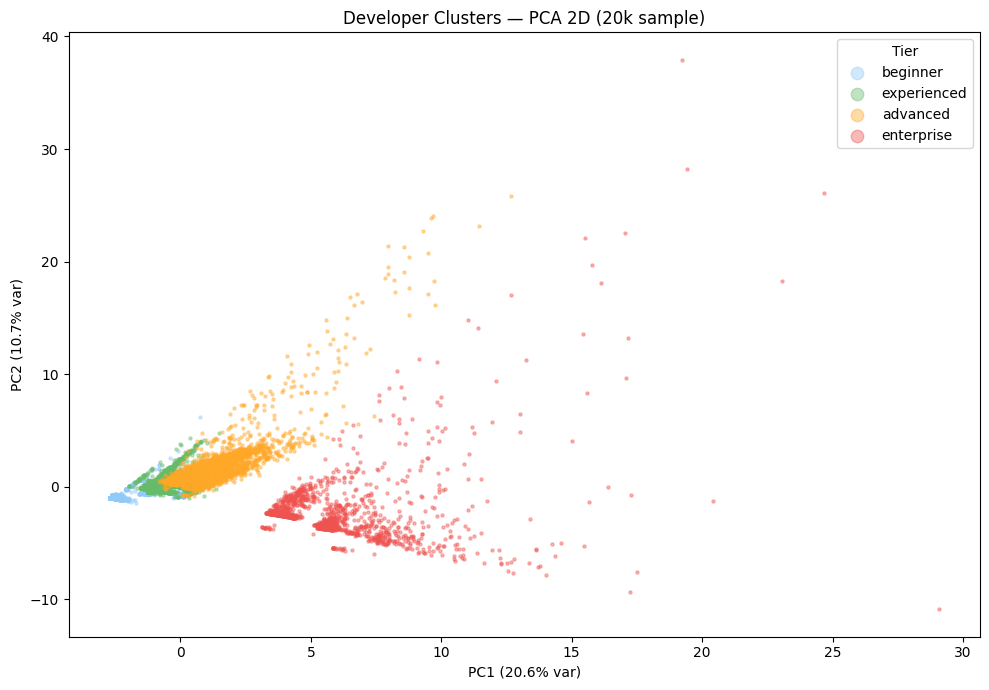

In [11]:
np.random.seed(SEED)
viz_idx = np.random.choice(len(X_scaled), size=20_000, replace=False)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled[viz_idx])
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 7))
for tier in TIER_ORDER:
    mask = labels[viz_idx] == tier
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=TIER_COLORS[tier], label=tier, alpha=0.4, s=5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Developer Clusters — PCA 2D (20k sample)")
ax.legend(title="Tier", markerscale=4)
plt.tight_layout(); plt.show()

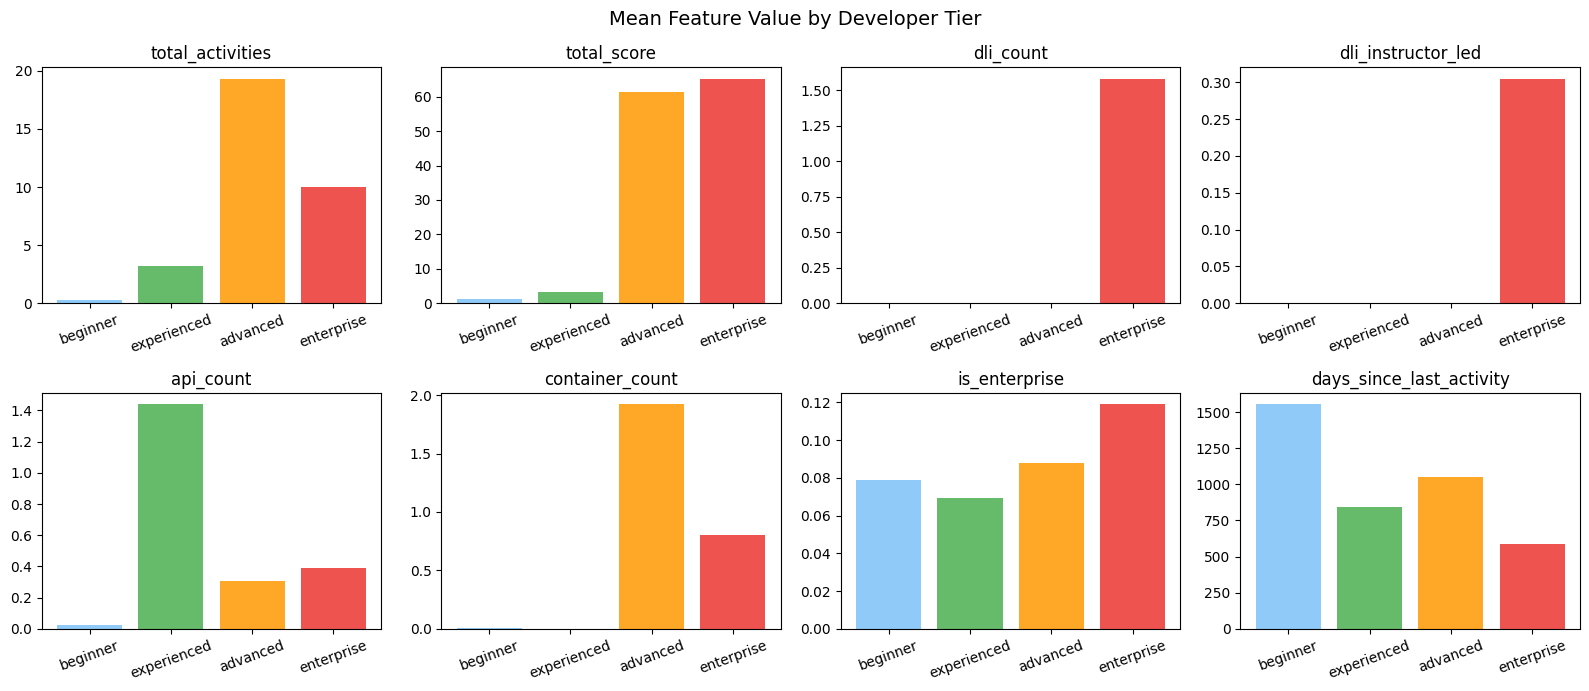

In [12]:
df_labeled = X_raw.copy()
df_labeled["tier"] = labels

plot_features = ["total_activities", "total_score", "dli_count", "dli_instructor_led",
                 "api_count", "container_count", "is_enterprise", "days_since_last_activity"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flatten(), plot_features):
    means = [df_labeled[df_labeled["tier"] == t][feat].mean() for t in TIER_ORDER]
    ax.bar(TIER_ORDER, means, color=[TIER_COLORS[t] for t in TIER_ORDER])
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Mean Feature Value by Developer Tier", fontsize=14)
plt.tight_layout(); plt.show()

In [13]:
summary_cols = ["total_activities", "total_score", "avg_score", "max_score",
                "dli_count", "dli_instructor_led", "api_count", "container_count",
                "hackathon_count", "forum_count", "is_enterprise", "is_wwfo_targeted",
                "tenure_days", "days_since_last_activity"]
summary = df_labeled.groupby("tier")[summary_cols].mean().round(2)
summary.insert(0, "count", df_labeled.groupby("tier").size())
summary.insert(1, "pct", (df_labeled.groupby("tier").size() / len(df_labeled) * 100).round(1))
display(summary.loc[TIER_ORDER])

,count,pct,total_activities,total_score,avg_score,max_score,dli_count,dli_instructor_led,api_count,container_count,hackathon_count,forum_count,is_enterprise,is_wwfo_targeted,tenure_days,days_since_last_activity
tier,,,,,,,,,,,,,,,,
beginner,2307163,24.60,0.28,1.14,1.06,1.06,0.00,0.00,0.02,0.00,0.00,0.00,0.08,0.07,0.35,1554.98
experienced,3672016,39.10,3.25,3.41,1.65,2.15,0.00,0.00,1.44,0.00,0.00,0.00,0.07,0.12,874.15,842.76
advanced,2322720,24.80,19.34,61.24,3.12,4.02,0.00,0.00,0.30,1.92,0.00,0.03,0.09,0.39,1464.01,1051.52
enterprise,1079591,11.50,10.02,65.24,12.75,24.56,1.58,0.31,0.39,0.80,0.00,0.02,0.12,0.24,724.28,588.65


### Cluster Interpretation

**Beginner**
Developers who have had minimal engagement with the NVIDIA ecosystem. Activity is dominated by basic file downloads (installers, documentation) with low cumulative scores. Many have been inactive for an extended period or joined recently. They have not yet engaged with advanced resources like DLI courses, APIs, or containers. This group represents the largest share of registered developers and is the primary target for onboarding and activation campaigns.

**Experienced**
Developers who are actively building with NVIDIA tools. They show consistent activity across multiple engagement types, such as API usage, container and model downloads, and self-paced DLI courses. Scores are moderate, reflecting regular but not yet deep technical investment. Tenure is typically longer than beginners. This group is well-positioned to be moved toward advanced resources with targeted content recommendations.

**Advanced**
Highly engaged technical developers with deep investment in the NVIDIA stack. Distinguishing signals include instructor-led DLI completions (highest-scoring activity at 40 pts), presenter or speaker roles at conferences (100 pts), hackathon participation, forum contributions, and bug reports. These developers have long tenure, broad activity spans, and high cumulative scores. They are power users and potential community advocates.

**Enterprise**
Developers affiliated with formal organizations: linked to an enterprise account, flagged in the WWFO high-value target list, and often part of a university or corporate program. Their individual activity levels may not be the highest, but their organizational context signals institutional adoption. This group is the primary target for enterprise sales motions, partnership programs, and volume licensing conversations.

## Section 6 — Save Results

In [ ]:
#results_df = pd.DataFrame({
#    "developer_id": developer_ids,
#    "cluster_id":   cluster_ids.tolist(),
#    "tier":         labels.tolist(),
#})
#con.execute("CREATE OR REPLACE TABLE developer_clusters AS SELECT * FROM results_df")
#con.execute("COPY developer_clusters TO 'Data/developer_clusters.csv' (HEADER, DELIMITER ',')")
#print("Saved to developer_clusters table and Data/developer_clusters.csv")
#print()
#print(results_df["tier"].value_counts()[TIER_ORDER].to_string())

In [ ]:
#for tier in TIER_ORDER:
#    sample = con.execute(f"""
#        SELECT dc.developer_id, dc.tier,
#               f.total_activities, f.total_score, f.dli_count, f.is_enterprise
#        FROM developer_clusters dc
#        JOIN developer_features f ON dc.developer_id = f.developer_id
#        WHERE dc.tier = '{tier}'
#        LIMIT 3
#    """).df()
#    print(f"\n--- {tier.upper()} ---")
#    display(sample)
#con.close()
#print("\nDone.")